In [ ]:
import pandas as pd
from bertopic import BERTopic
import matplotlib.pyplot as plt

In [111]:
df = pd.read_csv("analysisData/depression_results.csv")
df.head()

,text,sentiment_label,sentiment_score,suicide_label,suicide_score
0,Its ironic how pepole say only adults can have...,0,0.995452,LABEL_0,0.999997
1,Wish my mind and consciousness could go dark w...,0,0.999735,LABEL_1,0.999750
2,And people are telling me oh it's way funner w...,0,0.990853,LABEL_0,0.999996
3,My parents got divorced on my birthday and I h...,1,0.977139,LABEL_0,0.999993
4,The Lord is close to the brokenhearted and sav...,1,0.997072,LABEL_1,0.999569


In [112]:
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(df["text"])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2941.33it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [113]:
topic_model.visualize_barchart()

In [114]:
topic_model.visualize_topics()

In [115]:
df['topic'] = topics
df['topic_probability'] = probs

In [116]:
sentiment_labels = {0: 'NEGATIVE', 1: 'POSITIVE'}
suicide_labels = {'LABEL_0': 'NON-SUICIDAL', 'LABEL_1': 'SUICIDAL'}

In [117]:
df['SENTIMENT'] = df['sentiment_label'].map(sentiment_labels)
df['SUICIDE'] = df['suicide_label'].map(suicide_labels)

In [119]:
df

,text,sentiment_label,sentiment_score,suicide_label,suicide_score,topic,topic_probability,SENTIMENT,SUICIDE
0,Its ironic how pepole say only adults can have...,0,0.995452,LABEL_0,0.999997,-1,0.000000,NEGATIVE,NON-SUICIDAL
1,Wish my mind and consciousness could go dark w...,0,0.999735,LABEL_1,0.999750,48,0.163450,NEGATIVE,SUICIDAL
2,And people are telling me oh it's way funner w...,0,0.990853,LABEL_0,0.999996,28,0.839307,NEGATIVE,NON-SUICIDAL
3,My parents got divorced on my birthday and I h...,1,0.977139,LABEL_0,0.999993,28,0.763491,POSITIVE,NON-SUICIDAL
4,The Lord is close to the brokenhearted and sav...,1,0.997072,LABEL_1,0.999569,31,1.000000,POSITIVE,SUICIDAL
...,...,...,...,...,...,...,...,...,...
12566,The dislikes are payed actors >:(,0,0.998714,LABEL_0,0.999994,60,0.447191,NEGATIVE,NON-SUICIDAL
12567,Too tired...,0,0.999764,LABEL_1,0.999997,12,1.000000,NEGATIVE,SUICIDAL
12568,firsttt,1,0.965051,LABEL_1,0.999883,13,0.447810,POSITIVE,SUICIDAL
12569,*Where's everyone listening from?* ❤️\n\nYou c...,0,0.999223,LABEL_0,0.999885,-1,0.000000,NEGATIVE,NON-SUICIDAL


In [120]:
df_filtered = df[(df['SENTIMENT'] == 'POSITIVE') & (df['SUICIDE'] == 'SUICIDAL')].reset_index()

In [121]:
df_filtered

,index,text,sentiment_label,sentiment_score,suicide_label,suicide_score,topic,topic_probability,SENTIMENT,SUICIDE
0,4,The Lord is close to the brokenhearted and sav...,1,0.997072,LABEL_1,0.999569,31,1.000000,POSITIVE,SUICIDAL
1,8,"You could be listening to polkas, waltzes, and...",1,0.727307,LABEL_1,0.996667,-1,0.000000,POSITIVE,SUICIDAL
2,23,Lost her 2 years ago and I cannot forget her. ...,1,0.966943,LABEL_1,0.999657,-1,0.000000,POSITIVE,SUICIDAL
3,33,me please help me please,1,0.981411,LABEL_1,0.996808,116,1.000000,POSITIVE,SUICIDAL
4,44,"Philippians 4:6-7:\n\n""Do not be anxious about...",1,0.998697,LABEL_1,0.728149,31,0.882542,POSITIVE,SUICIDAL
...,...,...,...,...,...,...,...,...,...,...
886,12491,Can't even cry I feel so empty.\nMaybe someday...,1,0.990549,LABEL_1,0.655434,0,0.658018,POSITIVE,SUICIDAL
887,12504,"No matter what happens in your life, you are a...",1,0.999757,LABEL_1,0.985626,-1,0.000000,POSITIVE,SUICIDAL
888,12522,Music is my way out...,1,0.993403,LABEL_1,0.999996,-1,0.000000,POSITIVE,SUICIDAL
889,12558,damn. i remember my dad who past away 3 years ...,1,0.604927,LABEL_1,0.999945,25,0.257950,POSITIVE,SUICIDAL


In [122]:
def cal_per(df, features):
    counts = df.groupby(features).size()
    percentages = counts / counts.sum() * 100
    percentages_df = percentages.reset_index(name='percentage')
    
    return percentages_df

percent_feature1 = cal_per(df, ['SENTIMENT'])
percent_feature2 = cal_per(df, ['SUICIDE'])

print(percent_feature1)
print(percent_feature2)

  SENTIMENT  percentage
0  NEGATIVE   66.788641
1  POSITIVE   33.211359
        SUICIDE  percentage
0  NON-SUICIDAL   76.692387
1      SUICIDAL   23.307613


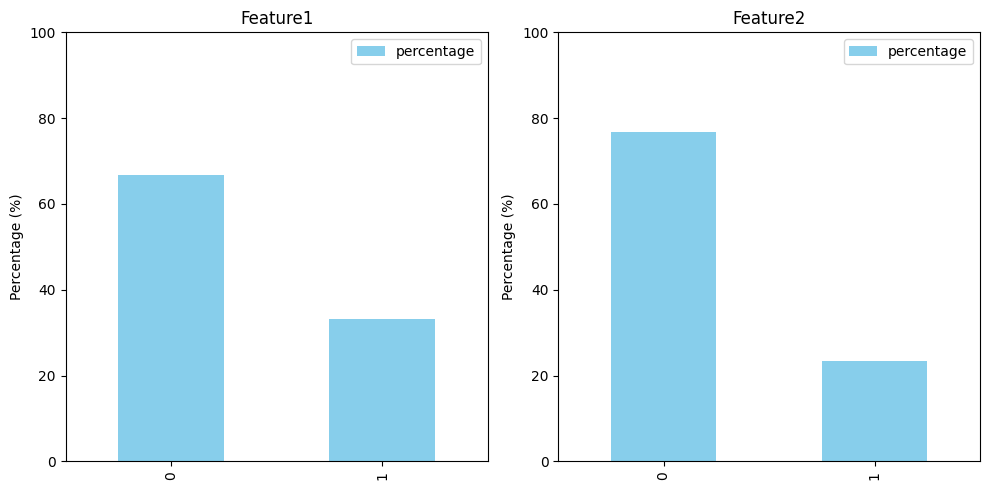

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

percent_feature1.plot(kind='bar', ax=ax[0], color=['skyblue','salmon'], title='Feature1')
percent_feature2.plot(kind='bar', ax=ax[1], color=['skyblue','salmon'], title='Feature2')

for a in ax:
    a.set_ylabel('Percentage (%)')
    a.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [124]:
features = ['SENTIMENT', 'SUICIDE']
percentages_df = cal_per(df, features)
percentages_df

,SENTIMENT,SUICIDE,percentage
0,NEGATIVE,NON-SUICIDAL,50.568769
1,NEGATIVE,SUICIDAL,16.219871
2,POSITIVE,NON-SUICIDAL,26.123618
3,POSITIVE,SUICIDAL,7.087742


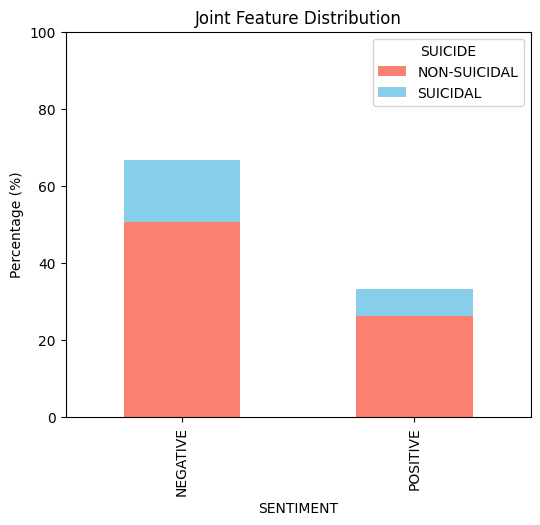

In [ ]:
pivot_df = percentages_df.pivot(index='SENTIMENT', columns='SUICIDE', values='percentage').fillna(0)

# stacked bar
pivot_df.plot(kind='bar', stacked=True, color=['salmon','skyblue'], figsize=(6,5))
plt.ylabel('Percentage (%)')
plt.title('Joint Feature Distribution')
plt.ylim(0, 100)
plt.show()

In [126]:
def filter(df, sentiment_label, suicide_label):
    df_filtered = df[(df['SENTIMENT'] == sentiment_label) & (df['SUICIDE'] == suicide_label)].reset_index()
    return df_filtered

In [139]:
dfs = []

for sui in suicide_labels .values():
    for sent in sentiment_labels.values():

        percentages_df = cal_per(filter(df, sent, sui), ['topic'])

        # rename percentage column to combination name
        percentages_df = percentages_df.rename(
            columns={"percentage": f"{sui}_{sent}"}
        )

        dfs.append(percentages_df)

result = dfs[0]

for d in dfs[1:]:
    result = result.merge(d, on="topic", how="outer")

result = result.fillna(0)
result[:10]

,topic,NON-SUICIDAL_NEGATIVE,NON-SUICIDAL_POSITIVE,SUICIDAL_NEGATIVE,SUICIDAL_POSITIVE
0,-1,44.281894,42.965895,44.139284,36.588103
1,0,4.200094,3.014616,1.667484,1.907969
2,1,3.083215,1.613886,3.285924,1.459035
3,2,2.516910,2.070646,1.177048,0.561167
4,3,1.085418,0.700365,5.002452,2.469136
5,4,0.283152,3.471376,0.490436,4.489338
6,5,1.447224,1.278928,0.735655,0.224467
7,6,0.644958,1.400731,1.471309,2.020202
8,7,0.928111,0.213155,2.648357,0.561167
9,8,0.597766,0.213155,3.334968,1.234568


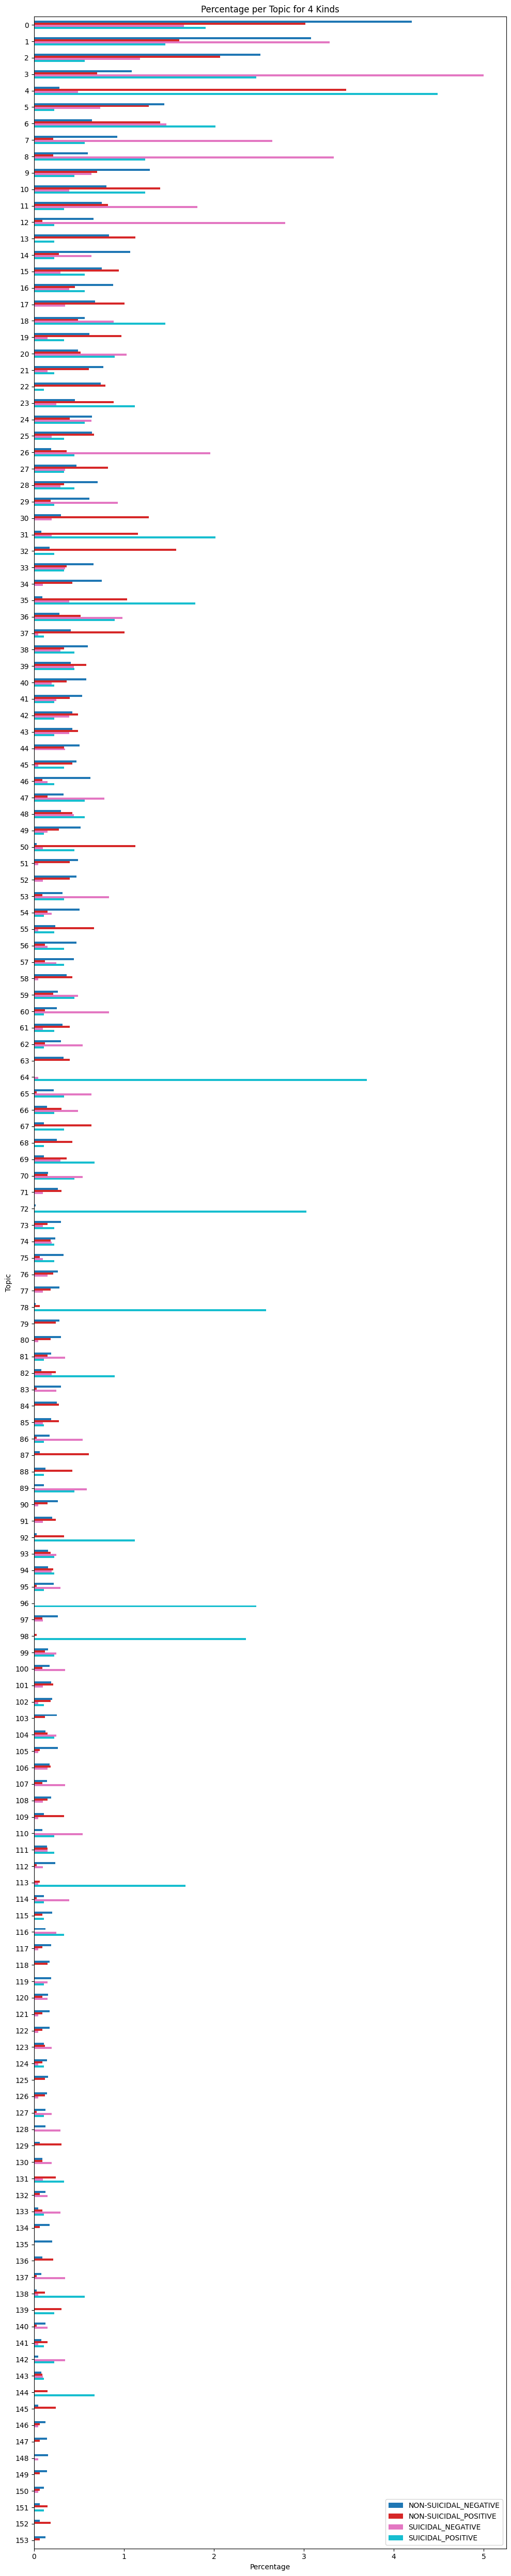

In [151]:

ax = result[1:].set_index("topic").plot(
    kind="barh",      # horizontal bars
    figsize=(10,50),
    colormap='tab10'  # optional nice color palette
)

ax.invert_yaxis()     # invert y-axis: first topic on top
ax.set_xlabel("Percentage")
ax.set_ylabel("Topic")
ax.set_title("Percentage per Topic for 4 Kinds")

plt.tight_layout()
plt.show()